# 3. Graph-EVT: одноканальная POT-детекция

**Цель:** применить `GraphEVTPipeline` к одномерному ряду, оценить POT/GPD-порог на начальном baseline и проверить наличие первого устойчивого превышения. Это детерминированный анализ библиотеки, не LLM-исследование. Для одного канала библиотека не строит граф или рейтинг источников и не выдаёт отдельные подгонки хвостов либо declustering-таблицы.

In [1]:
from pathlib import Path
from importlib.metadata import version
import json
import numpy as np
import pandas as pd
from graph_evt_agent import EVTConfig, GraphConfig, GraphEVTPipeline, InputConfig

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data/generated/additive_fractal_series.csv").exists())
DATA = ROOT / "data/generated/additive_fractal_series.csv"
SEED = 42
df = pd.read_csv(DATA)
x = df["value"].to_numpy()
event_mask = df["is_extreme"].to_numpy(dtype=bool)
assert np.isfinite(x).all() and x.ndim == 1
assert event_mask.shape == x.shape and event_mask.any()
event_start = int(np.flatnonzero(event_mask)[0])
event_end = int(np.flatnonzero(event_mask)[-1])

In [2]:
BASELINE_SIZE = event_start
evt_config = EVTConfig(
    baseline_size=BASELINE_SIZE,
    tail_quantile=0.95,
    alarm_probability=0.999,
    persistence=3,
)
pipeline = GraphEVTPipeline(
    evt_config,
    graph=GraphConfig(random_state=SEED),
    input_config=InputConfig(missing="error"),
    verbose=True,
)
result = pipeline.run_detailed(x)
detection = result.detection
alarm_index = detection.time_index
detected_in_labeled_event = alarm_index is not None and bool(event_mask[int(alarm_index)])
detection_delay = int(alarm_index) - event_start if detected_in_labeled_event else None

pd.DataFrame([{
    "observations": result.input_profile.n_time,
    "baseline_size": BASELINE_SIZE,
    "labeled_event_start": event_start,
    "labeled_event_end": event_end,
    "alarm_threshold": detection.alarm_threshold,
    "detected": detection.detected,
    "time_index": alarm_index,
    "detected_in_labeled_event": detected_in_labeled_event,
    "detection_delay_samples": detection_delay,
    "graph_available": result.graph is not None,
}])

Graph-EVT pipeline:   0%|          | 0/3 [00:00<?, ?it/s]

,observations,baseline_size,labeled_event_start,labeled_event_end,alarm_threshold,detected,time_index,detected_in_labeled_event,detection_delay_samples,graph_available
0,1500,1000,1000,1149,2.06665,True,1124,True,124,False


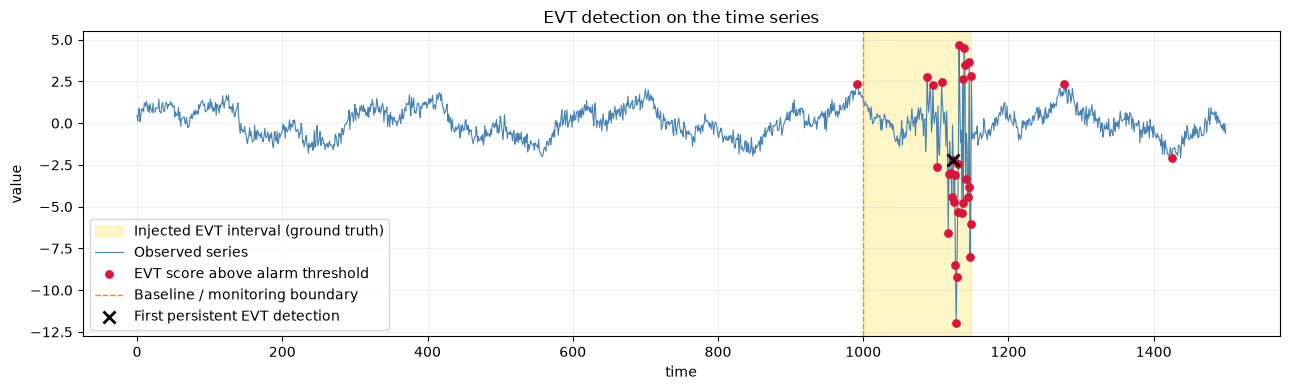

In [3]:
import matplotlib.pyplot as plt

above_alarm = detection.indicator > detection.alarm_threshold
fig, ax = plt.subplots(figsize=(13, 4))
ax.axvspan(
    df["timestamp"].iloc[event_start],
    df["timestamp"].iloc[event_end],
    color="gold",
    alpha=0.22,
    label="Injected EVT interval (ground truth)",
)
ax.plot(df["timestamp"], x, color="steelblue", linewidth=0.8, label="Observed series")
ax.scatter(
    df.loc[above_alarm, "timestamp"],
    x[above_alarm],
    color="crimson",
    s=28,
    zorder=3,
    label="EVT score above alarm threshold",
)
ax.axvline(
    df["timestamp"].iloc[BASELINE_SIZE],
    color="darkorange",
    linestyle="--",
    linewidth=1,
    label="Baseline / monitoring boundary",
)
if detection.detected and detection.time_index is not None:
    detection_index = int(detection.time_index)
    ax.scatter(
        df["timestamp"].iloc[detection_index],
        x[detection_index],
        color="black",
        marker="x",
        s=75,
        linewidth=2,
        zorder=4,
        label="First persistent EVT detection",
    )
ax.set(title="EVT detection on the time series", xlabel="time", ylabel="value")
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()

In [4]:
artifact_dir = ROOT / "results/1-d"
artifact_dir.mkdir(parents=True, exist_ok=True)

indicator_frame = pd.DataFrame({
    "time": df["timestamp"],
    "value": x,
    "is_extreme": event_mask,
    "indicator": detection.indicator,
    "above_alarm_threshold": detection.indicator > detection.alarm_threshold,
    "is_baseline": np.arange(len(x)) < BASELINE_SIZE,
})
indicator_frame.to_csv(artifact_dir / "03_evt_indicator.csv", index=False)

provenance = {
    "library": "graph-evt-agent",
    "library_version": version("graph-evt-agent"),
    "input_file": DATA.name,
    "observations": result.input_profile.n_time,
    "seed": SEED,
    "configuration": {
        "baseline_size": BASELINE_SIZE,
        "baseline_selection": "labeled_event_start_oracle_assisted",
        "tail_quantile": evt_config.tail_quantile,
        "alarm_probability": evt_config.alarm_probability,
        "persistence": evt_config.persistence,
    },
    "labeled_event": {"start": event_start, "end": event_end},
    "detection": {
        "detected": detection.detected,
        "time_index": detection.time_index,
        "detected_in_labeled_event": detected_in_labeled_event,
        "detection_delay_samples": detection_delay,
        "alarm_threshold": float(detection.alarm_threshold),
        "location": detection.location.tolist(),
        "scale": detection.scale.tolist(),
    },
    "graph_available": result.graph is not None,
    "ranking_available": result.ranking is not None,
}
with (artifact_dir / "03_evt_provenance.json").open("w", encoding="utf-8") as file:
    json.dump(provenance, file, indent=2)

provenance

{'library': 'graph-evt-agent',
 'library_version': '0.1.0',
 'input_file': 'additive_fractal_series.csv',
 'observations': 1500,
 'seed': 42,
 'configuration': {'baseline_size': 1000,
  'baseline_selection': 'labeled_event_start_oracle_assisted',
  'tail_quantile': 0.95,
  'alarm_probability': 0.999,
  'persistence': 3},
 'labeled_event': {'start': 1000, 'end': 1149},
 'detection': {'detected': True,
  'time_index': 1124,
  'detected_in_labeled_event': True,
  'detection_delay_samples': 124,
  'alarm_threshold': 2.066649951679863,
  'location': [0.10434685962976739],
  'scale': [1.0596705688152315]},
 'graph_available': False,
 'ranking_available': False}

Оценка использует робастные центр и масштаб чистого участка до начала размеченного синтетического события, двусторонний score абсолютного отклонения и POT/GPD-калибровку alarm-порога. Метка `is_extreme` используется только для выбора baseline и последующей оценки: детектор получает только значения временного ряда. На этом наборе первое устойчивое срабатывание находится внутри события; задержка измеряется от его начала.

Выбор baseline здесь oracle-assisted и недоступен для неразмеченных реальных данных. Проверяйте чувствительность к `tail_quantile`, `alarm_probability` и `persistence`; знак отклонения объединён в один score. Эта версия библиотеки не строит отдельные положительный/отрицательный tail fits и не выполняет declustering. Для одного канала граф и ranking закономерно отсутствуют.

**Самопроверка:** как загрязнение baseline событием влияет на порог? Что теряется при объединении двух направлений отклонения? Почему для одного канала нельзя локализовать источник?